In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from utils.Utils import (
    CanonicalUnits, 
    GravitationalParameters, 
    trasformation_X_to_E, 
    compute_jacobian_XoE,
    trasformation_E_to_X, 
    computeNumericalJacobian,
)
import numpy as np
import multimin as mm
from tqdm import tqdm
import matplotlib.pyplot as plt
import spiceypy as spy
import seaborn as sns
import plotly.graph_objects as go


\begin{equation}
    p(\widetilde{X})|d\widetilde{X}| = \eta(\widetilde{\varepsilon})|d\widetilde{\varepsilon}|
\end{equation}

\begin{equation}
    p(\widetilde{X}) = \eta(\widetilde{\varepsilon})|\frac{d\widetilde{\varepsilon}}{d\widetilde{X}}|
\end{equation}

\begin{equation}
    p(\widetilde{X}) = \eta(\widetilde{\varepsilon}(\widetilde{X}))\text{ det }\mathbb{J}_{\varepsilon \widetilde{X}}
\end{equation}

Where 


I have a trasformation between bounded and unbounded orbital elements (a,e,i) -> (A,E,I) given by 

\begin{equation}
    A = Ln(\frac{a}{a_{max} - a}) 
\end{equation}

\begin{equation}
    E = Ln(\frac{e}{e_{max} - e}) 
\end{equation}

\begin{equation}
    I = Ln(\frac{i}{i_{max} - i}) 
\end{equation}

please give me the jacobian matriz of this trasformation between bounded (a,e,i) and unbounded (A,E,I) orbital elements

In [3]:
deg = np.pi/180
AU_m = 1.496e11 #m
M_sun = 1.9891e30
G = 6.67430e-11 # m^3 / (kg s^2)
year = 365.25*24*3600 #s
mu = CanonicalUnits().mu
grav_params = GravitationalParameters(mu=mu)

### Testing Jacobian using q instead of a

In [4]:
a = 0.5
e = 0.1
i = np.pi/2
Omega = np.pi
w = np.pi
M = np.pi
q = a*(1-e)

J = compute_jacobian_XoE(a,e,i,w,Omega,M,mu)

In [5]:
J

array([[-1.22222222e+00, -1.11111111e+00,  1.25333620e-31,
        -6.73555740e-17,  1.02342668e-15,  8.98241160e-16],
       [ 1.49679053e-16,  1.36071867e-16,  1.02342668e-15,
        -5.50000000e-01, -3.36777870e-17, -2.76933677e-17],
       [ 2.27428151e-15,  1.13744923e-15,  6.16297582e-32,
         0.00000000e+00,  5.50000000e-01,  4.52267017e-01],
       [-1.77391654e-14, -6.07629559e-15,  9.84438316e-16,
         4.92219158e-16,  8.03854889e+00,  7.34458692e+00],
       [ 5.46910176e-16,  7.70646157e-16,  8.03854889e+00,
         1.59652489e-14, -9.84438316e-16, -8.99452486e-16],
       [-8.93172099e+00, -1.25856068e+01,  4.92219158e-16,
         0.00000000e+00, -1.59652489e-14, -1.36666294e-14]])

In [6]:
E = [q, e, i, Omega, w, M]
E2X = lambda E, mu: spy.conics(E+[0, mu], 0)
dX=np.array([1e-3]*6)
args=dict(mu=mu)
E_num, JXoE_comp=computeNumericalJacobian(E2X,E,dX,**args)
JXoE_comp

array([[-1.22222222e+00, -1.11111248e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00, -1.11022302e-13],
       [ 1.49679053e-16,  1.36072035e-16,  2.05339955e-16,
        -5.49999908e-01, -3.36777814e-17, -2.76933643e-17],
       [-1.36952207e-13, -2.72707654e-13,  0.00000000e+00,
         0.00000000e+00,  5.49999908e-01,  4.52266960e-01],
       [-3.58961694e-12, -1.79880252e-12,  9.84438152e-16,
         4.92219076e-16,  8.03854755e+00,  7.34458628e+00],
       [ 5.46911864e-16,  7.70646442e-16,  8.03854755e+00,
         5.20179705e-15, -9.84438152e-16, -8.99452407e-16],
       [-8.93174855e+00, -1.25856115e+01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

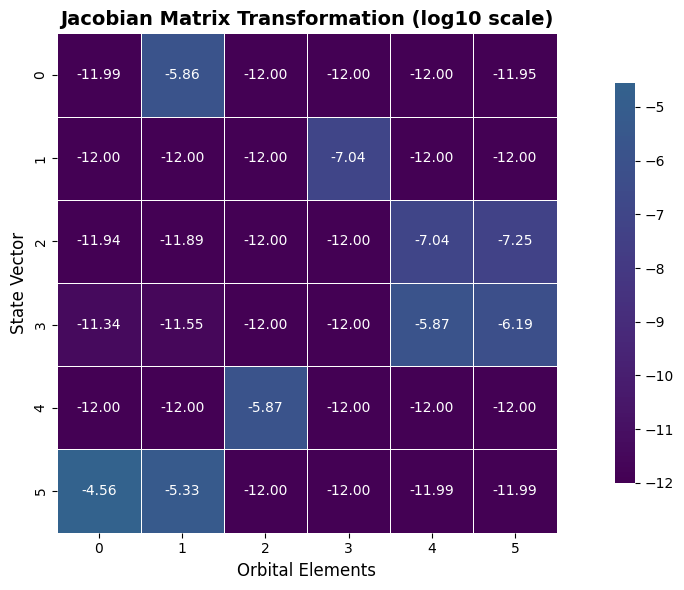

In [7]:
plt.figure(figsize=(12, 6))

# Apply log10 to absolute values, add epsilon to avoid log(0)
eps = 1e-12
data_log = np.log10(np.abs(JXoE_comp - J) + eps)

# Create heatmap
sns.heatmap(data_log, 
            annot=True, 
            fmt='.2f',   # no need for scientific notation, since log scale
            cmap='viridis', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title(f'Jacobian Matrix Transformation (log10 scale)', fontsize=14, fontweight='bold')
plt.xlabel('Orbital Elements', fontsize=12)
plt.ylabel('State Vector', fontsize=12)
plt.tight_layout()
plt.show()

### Veryfing CMND fit 

C:\Users\aguju\Documents\tesis\juanita\juanita\repo\TesisRepo\jacobian_calculations\multimin.py:255: UserWarning: The figure layout has changed to tight
  self.fig.tight_layout()


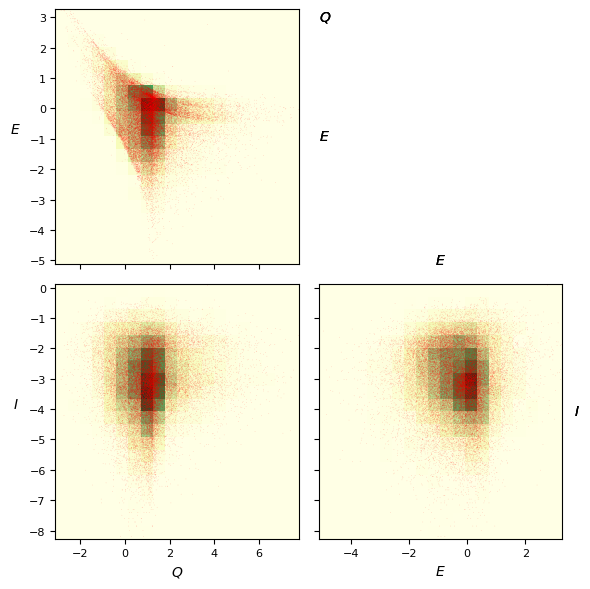

In [8]:
F = mm.FitCMND(f"../../multimin/products/fit-NEAs-qei-Ng10-Nv3-rad.pkl")

props=["Q","E","I"]
hargs=dict(bins=20,cmap='YlGn')
sargs=dict(s=0.2,edgecolor='None',color='r', alpha=0.3)
G=F.plotFit(props=props,hargs=hargs,sargs=sargs,figsize=3)

In [9]:
def P_E_CMND(a: float, e: float, i: float, F: mm.FitCMND) -> float:
    max = 2*np.pi; min = 0

    q = a*(1-e)
    element = np.array([q, e, i])
    scales=[1.35,1.00,np.pi]
    u_element = mm.Util.tIF(element, scales, mm.Util.f2u)

    P_qei = F.cmnd.pdf(u_element)
    P_WwM = 1/(max - min)**3

    return P_qei * P_WwM

In [10]:
def Jacobian_qei_to_QEI(q: float, e: float, i: float, q_max: float, e_max: float, i_max: float) -> np.array:
    partialA_a = q_max/(q*(q_max - q))
    partialA_e = 0
    partialA_i = 0
    partialE_a = 0
    partialE_e = e_max/(e*(e_max - e))
    partialE_i = 0
    partialI_a = 0
    partialI_e = 0
    partialI_i = i_max/(i*(i_max - i))

    Jacobian = np.array([[partialA_a, partialA_e, partialA_i], [partialE_a, partialE_e, partialE_i], [partialI_a, partialI_e, partialI_i]])
    return Jacobian

In [11]:
def P_X_CMND(x: np.array, y: np.array, z: np.array, vx: np.array, vy: np.array, vz: np.array, q_max: float, e_max: float, i_max: float, mu: float, F: mm.FitCMND) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx)
    vy = np.asarray(vy)
    vz = np.asarray(vz)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()

    for idx in range(x_flat.size):
        a, e, i, Omega, w, M = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        q = a*(1-e)
        J = compute_jacobian_XoE(a,e,i,Omega,w,M,mu)
        J_qei_to_QEI = Jacobian_qei_to_QEI(q,e,i,q_max,e_max,i_max)
        with np.errstate(divide='ignore', invalid='ignore'):
            det = np.linalg.det(J)
            det_QEI = np.linalg.det(J_qei_to_QEI)
            #print(x_flat[idx], y_flat[idx], z_flat[idx],  vx_flat[idx], vy_flat[idx], vz_flat[idx])
            #print(det)
            if det == 0 or not np.isfinite(det):
                print("Problematic point: ", x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx])
                P.flat[idx] = np.nan
            else:
                inv_det = 1.0/det 
                #print(P_E_CMND(a, e, i, F) * abs(inv_det) * abs(det_AEI)) 
                P.flat[idx] = P_E_CMND(a, e, i, F) * abs(inv_det) * abs(det_QEI)
                
    return P.reshape(shape)

In [12]:
N = int(1e7)
fit_sample = F.cmnd.rvs(Nsam=N)

In [13]:
scales=[1.35,1.00,np.pi]
converted_sample = np.zeros_like(fit_sample)
for i, element in enumerate(fit_sample):
    converted_sample[i] = mm.Util.tIF(element, scales, mm.Util.u2f)

converted_sample

array([[1.03015914, 0.34284864, 0.11751736],
       [1.30676877, 0.42692735, 0.14015342],
       [1.00048448, 0.17942657, 0.18416913],
       ...,
       [1.20297269, 0.57028968, 0.08011755],
       [0.65729893, 0.51141272, 0.35379217],
       [0.4018887 , 0.62591718, 0.09497449]])

In [14]:
N = int(1e7)

q_CMND = converted_sample[:,0]
e_CMND = converted_sample[:,1]
i_CMND = converted_sample[:,2]

Omega_uniform = np.random.uniform(0, 2*np.pi, N)
w_uniform = np.random.uniform(0, 2*np.pi, N)
M_uniform = np.random.uniform(0, 2*np.pi, N)


elements = np.column_stack((q_CMND, e_CMND, i_CMND, Omega_uniform, w_uniform, M_uniform))

state_vectors = np.zeros((N, 6))
for el in tqdm(range(N)):
    q = q_CMND[el]
    e = e_CMND[el]
    i = i_CMND[el]
    Omega = Omega_uniform[el]
    w = w_uniform[el]
    M = M_uniform[el]
    a = q/(1-e)

    x, y, z, vx, vy, vz = trasformation_E_to_X(a, e, i, Omega, w, M, mu)
    state_vectors[el] = np.array([x, y, z, vx, vy, vz])

100%|██████████| 10000000/10000000 [01:42<00:00, 97862.36it/s]


In [21]:
q_max, e_max, i_max = (1.3, 1.0, np.pi)

xmin, xmax = (0.9039710143502464, 1.0960289856497536)
ymin, ymax = ( -0.09602898564975362, 0.09602898564975362)
zmin, zmax = (-0.09602898564975362, 0.09602898564975362)
vxmin, vxmax = (-0.5064245183055923, 0.5064245183055923)
vymin, vymax = (5.777598212496408, 6.790447249107593)
vzmin, vzmax = (-0.5064245183055923, 0.5064245183055923)

X = np.linspace(xmin, xmax, 100)
Y = np.linspace(ymin, ymax, 100)
Z = np.linspace(zmin, zmax, 100)
VX = np.linspace(vxmin, vxmax, 100)
VY = np.linspace(vymin, vymax, 100)
VZ = np.linspace(vzmin, vzmax, 100)

X_malla, Y_malla = np.meshgrid(X, Y)
X_malla, Z_malla = np.meshgrid(X, Z)
VX_malla, VY_malla = np.meshgrid(VX, VY)
VX_malla, VZ_malla = np.meshgrid(VX, VZ)

zero_vector = np.zeros_like(X_malla) + 0.1

P_XY = P_X_CMND(x=X_malla, y=Y_malla, z=zero_vector, vx=zero_vector, vy=zero_vector, vz=zero_vector, q_max=q_max, e_max=e_max, i_max=i_max, mu=mu, F=F)
P_XZ = P_X_CMND(x=X_malla, y=zero_vector, z=Z_malla, vx=zero_vector, vy=zero_vector, vz=zero_vector, q_max=q_max, e_max=e_max, i_max=i_max, mu=mu, F=F)
P_VXY = P_X_CMND(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=VY_malla, vz=zero_vector, q_max=q_max, e_max=e_max, i_max=i_max, mu=mu, F=F)
P_VXZ = P_X_CMND(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=zero_vector, vz=VZ_malla, q_max=q_max, e_max=e_max, i_max=i_max, mu=mu, F=F)

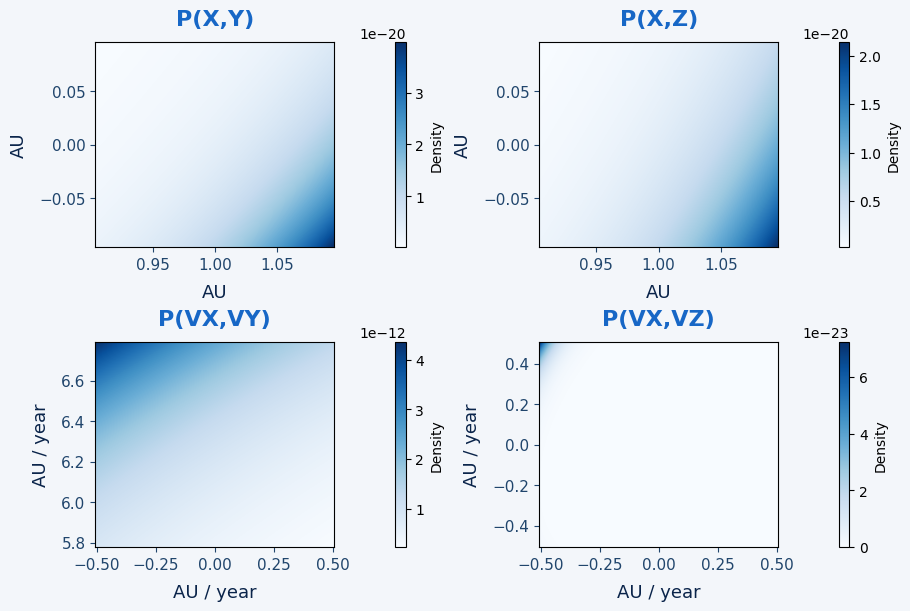

In [22]:
plot_configs = [
    {
        "data": P_XY,
        "extent": [xmin, xmax, ymin, ymax],
        "title": "P(X,Y)",
        "xlabel": "AU",
        "ylabel": "AU"
    },
    {
        "data": P_XZ,
        "extent": [xmin, xmax, zmin, zmax],
        "title": "P(X,Z)",
        "xlabel": "AU",
        "ylabel": "AU"
    },
    {
        "data": P_VXY,
        "extent": [vxmin, vxmax, vymin, vymax],
        "title": "P(VX,VY)",
        "xlabel": "AU / year",
        "ylabel": "AU / year"
    },
    {
        "data": P_VXZ,
        "extent": [vxmin, vxmax, vzmin, vzmax],
        "title": "P(VX,VZ)",
        "xlabel": "AU / year",
        "ylabel": "AU / year"
    }
]

# Use 'Blues' colormap and customize plot styling
fig, axes = plt.subplots(2, 2, figsize=(9, 6), constrained_layout=True, facecolor="#f3f6fa")

for i, ax in enumerate(axes.flat):
    im = ax.imshow(
        plot_configs[i]["data"],
        origin='lower',
        cmap='Blues',
        interpolation='bilinear',
        extent=plot_configs[i]["extent"],
        aspect='auto'
    )
    ax.set_title(
        plot_configs[i]["title"], 
        fontsize=16, 
        color="#1767c6", 
        pad=12, 
        weight='bold'
    )
    ax.set_xlabel(plot_configs[i]["xlabel"], fontsize=13, color="#0a244a", labelpad=8)
    ax.set_ylabel(plot_configs[i]["ylabel"], fontsize=13, color="#0a244a", labelpad=8)
    ax.tick_params(axis='both', which='major', labelsize=11, colors='#20456c')
    #ax.spines['top'].set_visible(False)
    #ax.spines['right'].set_visible(False)
    fig.colorbar(
        im, 
        ax=ax, 
        fraction=0.045, 
        pad=0.04, 
        orientation='vertical', 
        label='Density'
    )
"""
plt.suptitle(
    'Probability Density Function $P(X)$ evaluated at the limits of the distribution state space vectors',
    fontsize=18,
    color='#15335b',
    fontweight='semibold',
    y=1.04
)
"""
plt.show()

In [15]:
def surface_integral_P_X_CMND(center, widths, max_elements: list, n_points=8, mu=1, F=mm.FitCMND):
    """
    Calculate the surface integral of P_xyvxvy in a hypercube centered at (x, y, vx, vy)
    with dimensions (dx, dy, dvx, dvy) using Gauss-Legendre quadrature.

    Parameters:
        center: tuple/list/array of (x, y, vx, vy) center
        widths: tuple/list/array of (dx, dy, dvx, dvy) side lengths
        max_elemetns: tuple/list/array of (a_max, e_max, i_max) max elements
        n_points: number of quadrature points per dimension

    Returns:
        Integral (float)
    """
    from numpy.polynomial.legendre import leggauss

    x0, y0, z0, vx0, vy0, vz0 = center
    dx, dy, dz, dvx, dvy, dvz = widths
    q_max, e_max, i_max = max_elements

    # Get Gauss-Legendre points and weights for [-1, 1]
    pts, wts = leggauss(n_points)

    # Map points from [-1, 1] to [center-width/2, center+width/2] for each dimension
    x_pts = x0 + 0.5*dx*pts
    y_pts = y0 + 0.5*dy*pts
    z_pts = z0 + 0.5*dz*pts
    vx_pts = vx0 + 0.5*dvx*pts
    vy_pts = vy0 + 0.5*dvy*pts
    vz_pts = vz0 + 0.5*dvz*pts

    # Create meshgrid of all quadrature points
    X, Y, Z, VX, VY, VZ = np.meshgrid(x_pts, y_pts, z_pts, vx_pts, vy_pts, vz_pts, indexing='ij')
    WX, WY, WZ, WVX, WVY, WVZ = np.meshgrid(wts, wts, wts, wts, wts, wts, indexing='ij')

    # Flatten for vectorized evaluation
    Xf = X.ravel()
    Yf = Y.ravel()
    Zf = Z.ravel()
    VXf = VX.ravel()
    VYf = VY.ravel()
    VZf = VZ.ravel()
    WF = (WX * WY * WZ * WVX * WVY * WVZ).ravel()
    # Evaluate P at all points
    Pf = P_X_CMND(Xf, Yf, Zf, VXf, VYf, VZf, q_max, e_max, i_max, mu, F=F)

    # Integral is sum(P * weight) * volume factor
    integral = np.sum(Pf * WF) * (0.5*dx) * (0.5*dy) * (0.5*dz) * (0.5*dvx) * (0.5*dvy) * (0.5*dvz)
    #return integral, y_points
    return integral

In [16]:
#max elements
max_elements = (1.3, 1.0, np.pi)

# Define center and widths of the phase-space hypercube
c_x = 1
c_y = 0
c_z = 0
v_x = 0
v_y = (mu/1)**0.5
v_z = 0

dxyz = 0.2
dvxyz = 5000 * (1/AU_m) * year 

center = (c_x, c_y, c_z, v_x, v_y, v_z)
widths = (dxyz, dxyz, dxyz, dvxyz, dvxyz, dvxyz)

# Theoretical: compute expected number of objects in the volume by integrating the distribution
N_theoretical = surface_integral_P_X_CMND(center, widths, max_elements=max_elements, n_points=8, mu=mu, F=F)
print(f"Theoretical (integral) number of objects in volume: {N_theoretical}")

Theoretical (integral) number of objects in volume: 0.00018942338313134718


In [17]:
print(f"Theoretical (integral) number of objects in volume: {N_theoretical * N}")

Theoretical (integral) number of objects in volume: 1894.233831313472


In [18]:
# Numerical: count number of objects in the volume from the sample
objsx = (abs(state_vectors[:,0] - c_x) <= dxyz/2) 
objsy = (abs(state_vectors[:,1] - c_y) <= dxyz/2) 
objsz = (abs(state_vectors[:,2] - c_z) <= dxyz/2) 
objsvx = (abs(state_vectors[:,3] - v_x) <= dvxyz/2) 
objsvy = (abs(state_vectors[:,4] - v_y) <= dvxyz/2) 
objsvz = (abs(state_vectors[:,5] - v_z) <= dvxyz/2) 

objects = objsx & objsy & objsz & objsvx & objsvy & objsvz
N_numeric = objects.sum()
print(f'Numerical (count) number of objects inside volume: {N_numeric}')
print('Ratio', (N_theoretical * N)/N_numeric)

Numerical (count) number of objects inside volume: 1828
Ratio 1.0362329492962101


\begin{equation}
    p(\widetilde{X})|d\widetilde{X}| = \eta(\widetilde{\varepsilon})|d\widetilde{\varepsilon}|
\end{equation}

\begin{equation}
    p(\widetilde{X}) = \eta(\widetilde{\varepsilon})|\frac{d\widetilde{\varepsilon}}{d\widetilde{X}}|
\end{equation}

\begin{equation}
    p(\widetilde{X}) = \eta(\widetilde{\varepsilon}(\widetilde{X}))\text{ det }\mathbb{J}_{\varepsilon \widetilde{X}}
\end{equation}

I have a trasformation between bounded and unbounded orbital elements (a,e,i) -> (A,E,I) given by 

\begin{equation}
    A = Ln(\frac{a}{a_{max} - a}) 
\end{equation}

\begin{equation}
    E = Ln(\frac{e}{e_{max} - e}) 
\end{equation}

\begin{equation}
    I = Ln(\frac{i}{i_{max} - i}) 
\end{equation}

please give me the jacobian matriz of this trasformation between bounded (a,e,i) and unbounded (A,E,I) orbital elements